# SQL Analysis — Hospital Business Queries

**Dataset:** `healthcare_admissions.csv` loaded into an in-memory SQLite database as table `admissions` (55,500 records, 2019–2024).

All queries below are real SQL (window functions, CTEs, recursive date spines) run against SQLite via Python — not pandas re-implementations. Each query is shown in full, followed by its result set and a chart where useful.

**Caveats carried over from earlier notebooks, since the same fields are reused here:**
- No `Department` column exists — Department KPIs use `Medical Condition` as a department/service-line proxy.
- No `ICU`/ward column exists — ICU Occupancy uses `Admission Type = 'Emergency'` as a proxy for acute/ICU-level demand.
- No patient ID exists — Readmission Rate and High-Risk Patients use repeat `Name` as a proxy for a returning patient, same caveat as the earlier readmission model.

*Author: Nusrat — Data Analyst @ Wmolex | Educator, Gurukul Institute of Advanced Technology*


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect(':memory:')


## 0. Load Data into SQLite

In [2]:
df = pd.read_csv('healthcare_admissions.csv')
df.columns = [c.replace(' ', '_') for c in df.columns]  # SQL-friendly column names
df.to_sql('admissions', conn, index=False, if_exists='replace')

conn.execute('CREATE INDEX idx_dates ON admissions(Date_of_Admission, Discharge_Date)')
conn.execute('CREATE INDEX idx_type ON admissions(Admission_Type)')
conn.execute('CREATE INDEX idx_name ON admissions(Name)')
conn.commit()

pd.read_sql("SELECT * FROM admissions LIMIT 5", conn)


,Name,Age,Gender,Blood_Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1. Top Diseases

Ranks medical conditions by patient volume.


In [3]:
query_top_diseases = '''
SELECT
    Medical_Condition,
    COUNT(*) AS patient_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM admissions), 2) AS pct_of_total
FROM admissions
GROUP BY Medical_Condition
ORDER BY patient_count DESC;
'''
top_diseases = pd.read_sql(query_top_diseases, conn)
top_diseases


,Medical_Condition,patient_count,pct_of_total
0,Arthritis,9308,16.77
1,Diabetes,9304,16.76
2,Hypertension,9245,16.66
3,Obesity,9231,16.63
4,Cancer,9227,16.63
5,Asthma,9185,16.55


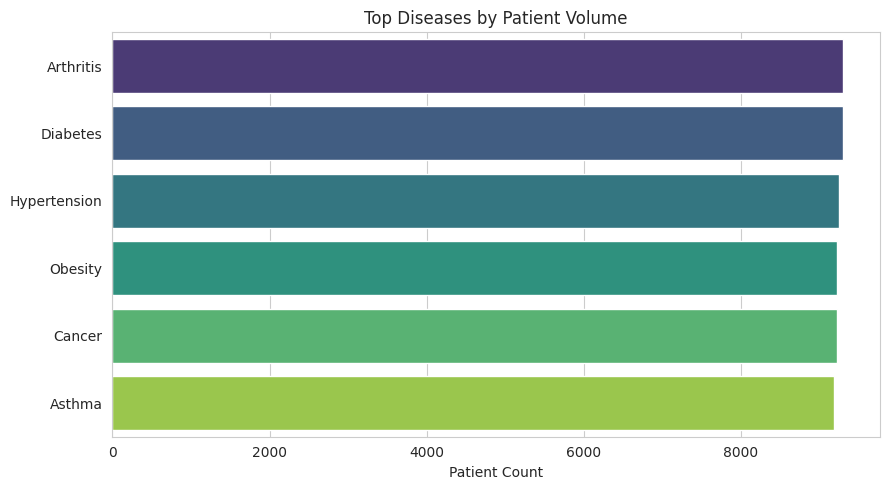

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=top_diseases, x='patient_count', y='Medical_Condition', palette='viridis')
plt.title('Top Diseases by Patient Volume')
plt.xlabel('Patient Count')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 2. Monthly Admissions

Admission volume trend by calendar month across the full date range.


In [5]:
query_monthly = '''
SELECT
    strftime('%Y-%m', Date_of_Admission) AS admission_month,
    COUNT(*) AS admissions
FROM admissions
GROUP BY admission_month
ORDER BY admission_month;
'''
monthly_admissions = pd.read_sql(query_monthly, conn)
monthly_admissions.head(10)


,admission_month,admissions
0,2019-05,686
1,2019-06,907
2,2019-07,957
3,2019-08,1001
4,2019-09,936
5,2019-10,1013
6,2019-11,959
7,2019-12,928
8,2020-01,950
9,2020-02,881


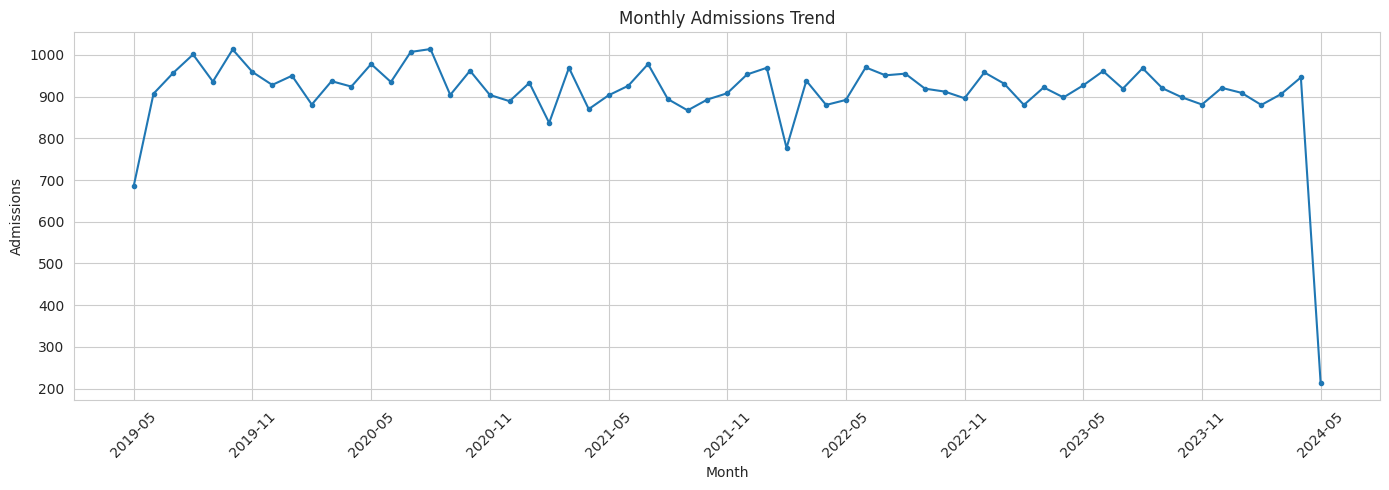

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_admissions['admission_month'], monthly_admissions['admissions'], marker='o', markersize=3)
plt.title('Monthly Admissions Trend')
plt.xlabel('Month')
plt.ylabel('Admissions')
plt.xticks(monthly_admissions['admission_month'][::6], rotation=45)
plt.tight_layout()
plt.show()


## 3. Revenue Analysis

Total and average billing by year and by admission type.


In [7]:
query_revenue_yearly = '''
SELECT
    strftime('%Y', Date_of_Admission) AS year,
    COUNT(*) AS admissions,
    ROUND(SUM(Billing_Amount), 2) AS total_revenue,
    ROUND(AVG(Billing_Amount), 2) AS avg_billing
FROM admissions
GROUP BY year
ORDER BY year;
'''
revenue_yearly = pd.read_sql(query_revenue_yearly, conn)
revenue_yearly


,year,admissions,total_revenue,avg_billing
0,2019,7387,1.898493e+08,25700.46
1,2020,11285,2.865516e+08,25392.25
2,2021,10931,2.801559e+08,25629.48
3,2022,11017,2.810823e+08,25513.51
4,2023,11026,2.819773e+08,25573.85
5,2024,3854,9.781566e+07,25380.30


In [8]:
query_revenue_by_type = '''
SELECT
    Admission_Type,
    COUNT(*) AS admissions,
    ROUND(SUM(Billing_Amount), 2) AS total_revenue,
    ROUND(AVG(Billing_Amount), 2) AS avg_billing
FROM admissions
GROUP BY Admission_Type
ORDER BY total_revenue DESC;
'''
revenue_by_type = pd.read_sql(query_revenue_by_type, conn)
revenue_by_type


,Admission_Type,admissions,total_revenue,avg_billing
0,Elective,18655,4.776095e+08,25602.23
1,Urgent,18576,4.740106e+08,25517.36
2,Emergency,18269,4.658119e+08,25497.40


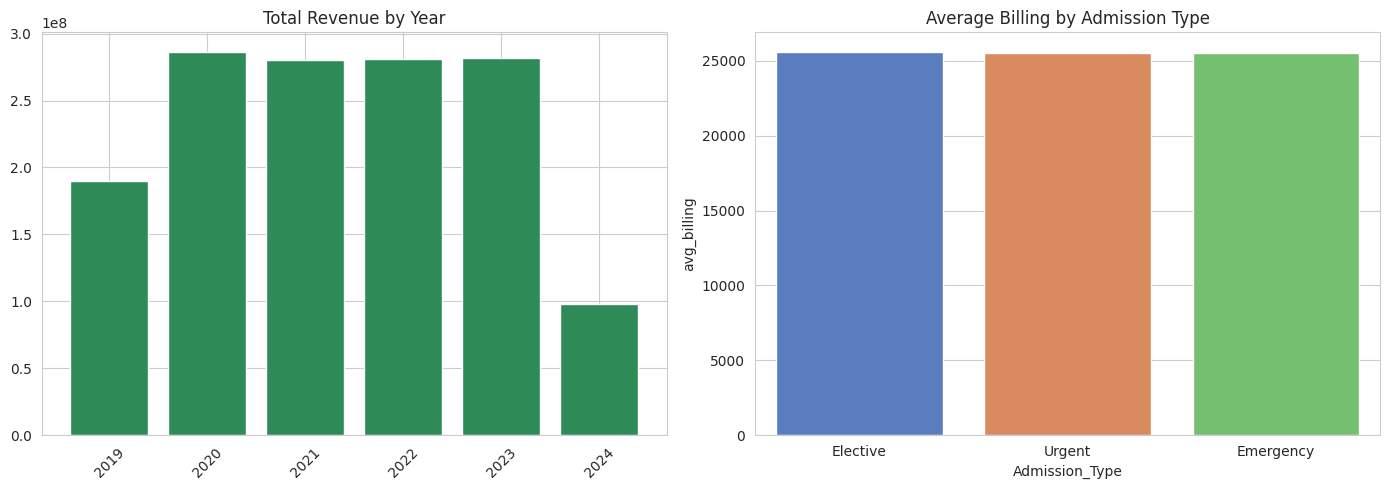

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(revenue_yearly['year'], revenue_yearly['total_revenue'], color='seagreen')
axes[0].set_title('Total Revenue by Year')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=revenue_by_type, x='Admission_Type', y='avg_billing', ax=axes[1], palette='muted')
axes[1].set_title('Average Billing by Admission Type')
plt.tight_layout()
plt.show()


## 4. Insurance Claims

Claim volume and billed amount by insurance provider.


In [10]:
query_insurance = '''
SELECT
    Insurance_Provider,
    COUNT(*) AS claim_count,
    ROUND(SUM(Billing_Amount), 2) AS total_billed,
    ROUND(AVG(Billing_Amount), 2) AS avg_claim_amount
FROM admissions
GROUP BY Insurance_Provider
ORDER BY total_billed DESC;
'''
insurance_claims = pd.read_sql(query_insurance, conn)
insurance_claims


,Insurance_Provider,claim_count,total_billed,avg_claim_amount
0,Cigna,11249,2.871393e+08,25525.77
1,Medicare,11154,2.857208e+08,25615.99
2,Blue Cross,11059,2.832543e+08,25613.01
3,UnitedHealthcare,11125,2.824545e+08,25389.17
4,Aetna,10913,2.788631e+08,25553.29


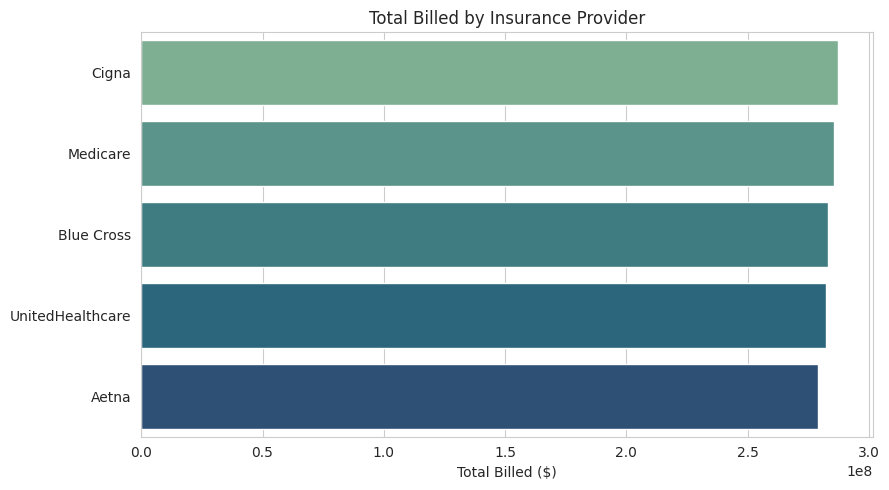

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(data=insurance_claims, x='total_billed', y='Insurance_Provider', palette='crest')
plt.title('Total Billed by Insurance Provider')
plt.xlabel('Total Billed ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Readmission Rate

Uses a window function to count visits per patient name, then computes the share of patients with more than one admission. ⚠️ Proxy metric — no patient ID exists, so this relies on exact name match.


In [12]:
query_readmission = '''
WITH patient_visits AS (
    SELECT
        Name,
        COUNT(*) AS visit_count
    FROM admissions
    GROUP BY Name
)
SELECT
    COUNT(*) AS total_patients,
    SUM(CASE WHEN visit_count > 1 THEN 1 ELSE 0 END) AS readmitted_patients,
    ROUND(100.0 * SUM(CASE WHEN visit_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS readmission_rate_pct
FROM patient_visits;
'''
readmission_rate = pd.read_sql(query_readmission, conn)
readmission_rate


,total_patients,readmitted_patients,readmission_rate_pct
0,49992,5507,11.02


In [13]:
query_readmission_by_condition = '''
WITH patient_visits AS (
    SELECT Name, Medical_Condition, COUNT(*) AS visit_count
    FROM admissions
    GROUP BY Name, Medical_Condition
)
SELECT
    Medical_Condition,
    COUNT(*) AS patients,
    SUM(CASE WHEN visit_count > 1 THEN 1 ELSE 0 END) AS readmitted,
    ROUND(100.0 * SUM(CASE WHEN visit_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS readmission_rate_pct
FROM patient_visits
GROUP BY Medical_Condition
ORDER BY readmission_rate_pct DESC;
'''
readmission_by_condition = pd.read_sql(query_readmission_by_condition, conn)
readmission_by_condition


,Medical_Condition,patients,readmitted,readmission_rate_pct
0,Obesity,8292,939,11.32
1,Cancer,8294,933,11.25
2,Hypertension,8319,926,11.13
3,Asthma,8272,913,11.04
4,Diabetes,8384,920,10.97
5,Arthritis,8438,870,10.31


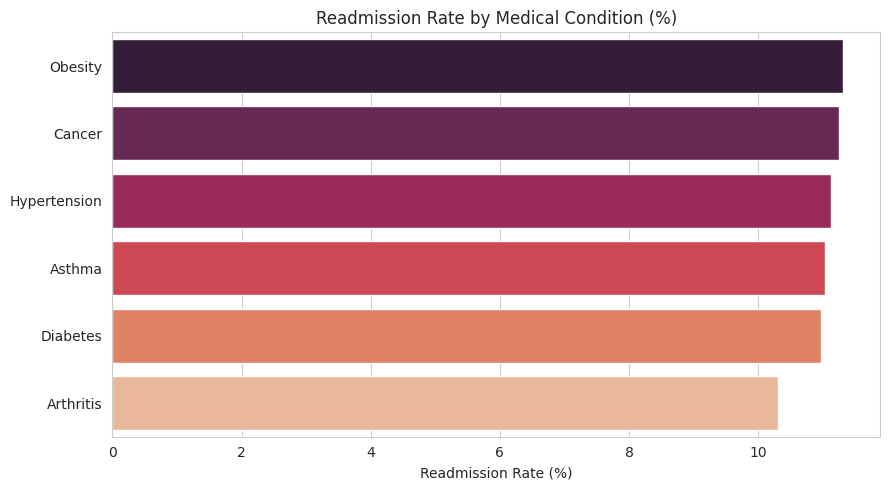

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=readmission_by_condition, x='readmission_rate_pct', y='Medical_Condition', palette='rocket')
plt.title('Readmission Rate by Medical Condition (%)')
plt.xlabel('Readmission Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 6. Department KPIs

⚠️ No `Department` column exists in the source data — `Medical_Condition` is used as a department/service-line proxy. KPIs: patient volume, average length of stay, average billing.


In [15]:
query_dept_kpis = '''
SELECT
    Medical_Condition AS department,
    COUNT(*) AS patient_count,
    ROUND(AVG(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS avg_length_of_stay,
    ROUND(AVG(Billing_Amount), 2) AS avg_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_revenue
FROM admissions
GROUP BY department
ORDER BY total_revenue DESC;
'''
dept_kpis = pd.read_sql(query_dept_kpis, conn)
dept_kpis


,department,patient_count,avg_length_of_stay,avg_billing,total_revenue
0,Diabetes,9304,15.42,25638.41,2.385397e+08
1,Obesity,9231,15.46,25805.97,2.382149e+08
2,Arthritis,9308,15.52,25497.33,2.373291e+08
3,Hypertension,9245,15.46,25497.10,2.357207e+08
4,Asthma,9185,15.70,25635.25,2.354598e+08
5,Cancer,9227,15.50,25161.79,2.321679e+08


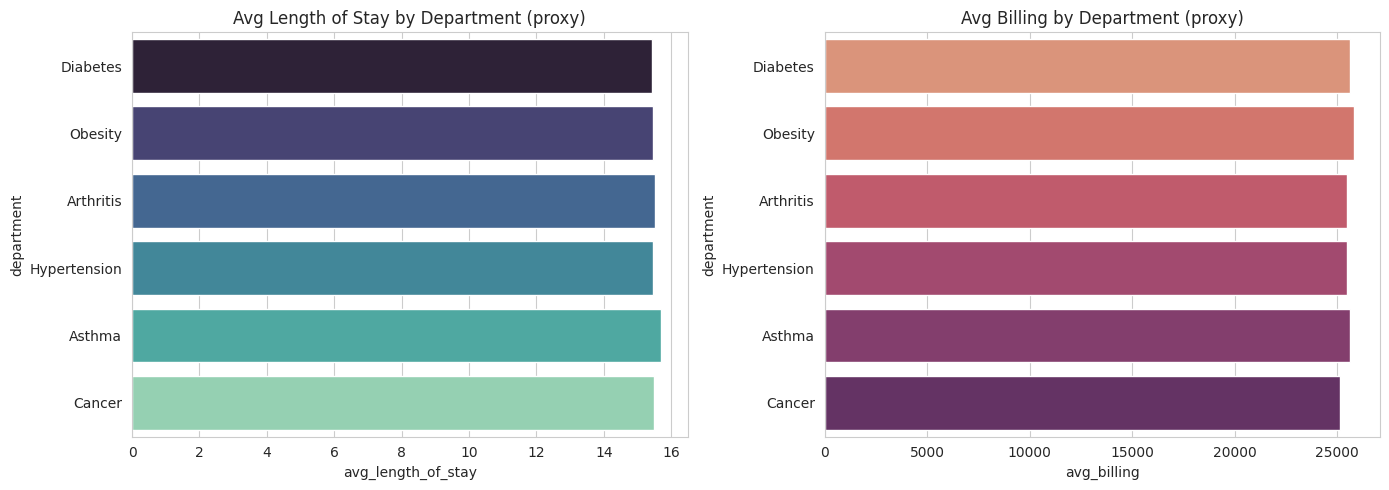

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=dept_kpis, x='avg_length_of_stay', y='department', ax=axes[0], palette='mako')
axes[0].set_title('Avg Length of Stay by Department (proxy)')

sns.barplot(data=dept_kpis, x='avg_billing', y='department', ax=axes[1], palette='flare')
axes[1].set_title('Avg Billing by Department (proxy)')
plt.tight_layout()
plt.show()


## 7. Doctor Performance

Top doctors by patient volume, with average billing and average length of stay per doctor.


In [17]:
query_doctor_perf = '''
SELECT
    Doctor,
    COUNT(*) AS patients_treated,
    ROUND(AVG(Billing_Amount), 2) AS avg_billing,
    ROUND(AVG(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS avg_length_of_stay,
    SUM(CASE WHEN Test_Results = 'Abnormal' THEN 1 ELSE 0 END) AS abnormal_results_count
FROM admissions
GROUP BY Doctor
ORDER BY patients_treated DESC
LIMIT 15;
'''
doctor_performance = pd.read_sql(query_doctor_perf, conn)
doctor_performance


,Doctor,patients_treated,avg_billing,avg_length_of_stay,abnormal_results_count
0,Michael Smith,27,29055.62,15.63,12
1,Robert Smith,22,28854.23,13.73,6
2,John Smith,22,27732.25,14.36,7
3,Michael Johnson,20,23040.95,18.70,5
4,James Smith,20,23090.90,17.30,8
5,Robert Johnson,19,27589.11,13.79,6
6,David Smith,19,24912.93,15.32,5
7,Michael Williams,18,17171.73,15.50,4
8,Matthew Smith,17,24790.30,13.76,3
9,John Johnson,17,27457.06,18.06,5


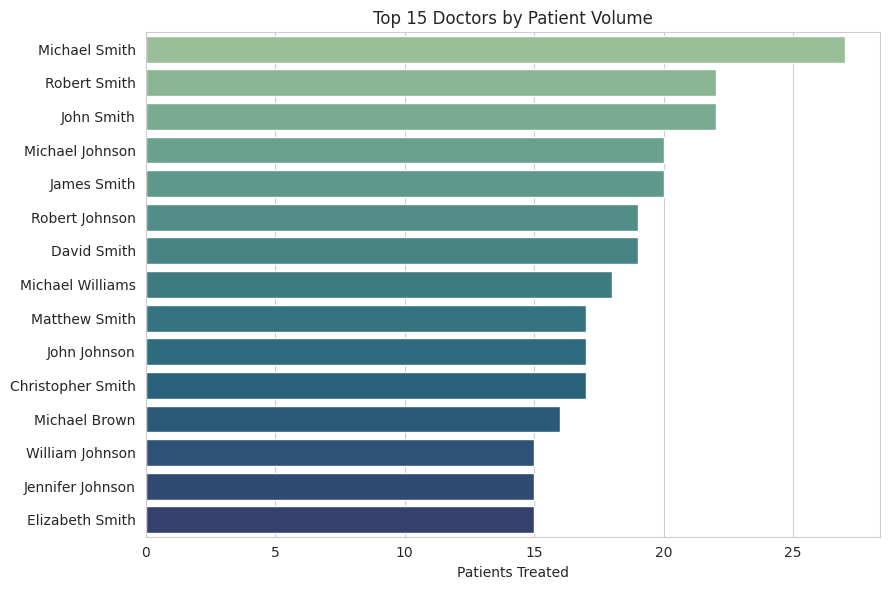

In [18]:
plt.figure(figsize=(9, 6))
sns.barplot(data=doctor_performance, x='patients_treated', y='Doctor', palette='crest')
plt.title('Top 15 Doctors by Patient Volume')
plt.xlabel('Patients Treated')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 8. Average Length of Stay

Overall average, plus breakdown by admission type and medical condition.


In [19]:
query_los_overall = '''
SELECT
    ROUND(AVG(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS avg_los_days,
    ROUND(MIN(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS min_los_days,
    ROUND(MAX(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS max_los_days
FROM admissions;
'''
los_overall = pd.read_sql(query_los_overall, conn)
los_overall


,avg_los_days,min_los_days,max_los_days
0,15.51,1.0,30.0


In [20]:
query_los_by_type = '''
SELECT
    Admission_Type,
    ROUND(AVG(julianday(Discharge_Date) - julianday(Date_of_Admission)), 2) AS avg_los_days
FROM admissions
GROUP BY Admission_Type
ORDER BY avg_los_days DESC;
'''
los_by_type = pd.read_sql(query_los_by_type, conn)
los_by_type


,Admission_Type,avg_los_days
0,Emergency,15.60
1,Elective,15.53
2,Urgent,15.41


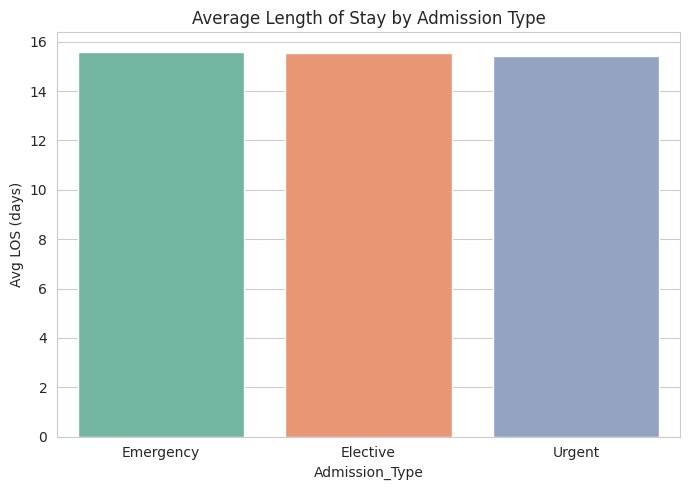

In [21]:
plt.figure(figsize=(7, 5))
sns.barplot(data=los_by_type, x='Admission_Type', y='avg_los_days', palette='Set2')
plt.title('Average Length of Stay by Admission Type')
plt.ylabel('Avg LOS (days)')
plt.tight_layout()
plt.show()


## 9. ICU Occupancy

⚠️ Proxy: no ICU field exists, so `Admission_Type = 'Emergency'` is used as a stand-in for acute/ICU-level demand. A recursive date-spine CTE generates one row per calendar day, then a range join counts how many "ICU" patients were active (admitted and not yet discharged) on each day.


In [22]:
query_icu_occupancy = '''
WITH RECURSIVE date_spine(day) AS (
    SELECT MIN(Date_of_Admission) FROM admissions
    UNION ALL
    SELECT date(day, '+1 day')
    FROM date_spine
    WHERE day < (SELECT MAX(Discharge_Date) FROM admissions)
)
SELECT
    ds.day,
    COUNT(a.Name) AS icu_occupancy
FROM date_spine ds
LEFT JOIN admissions a
    ON a.Admission_Type = 'Emergency'
    AND a.Date_of_Admission <= ds.day
    AND a.Discharge_Date >= ds.day
GROUP BY ds.day
ORDER BY ds.day;
'''
icu_occupancy = pd.read_sql(query_icu_occupancy, conn)
icu_occupancy['day'] = pd.to_datetime(icu_occupancy['day'])
icu_occupancy.describe()


,day,icu_occupancy
count,1857,1857.000000
mean,2021-11-21 00:00:00,163.260635
min,2019-05-08 00:00:00,1.000000
25%,2020-08-14 00:00:00,155.000000
50%,2021-11-21 00:00:00,165.000000
75%,2023-02-28 00:00:00,175.000000
max,2024-06-06 00:00:00,219.000000
std,NaN,23.163910


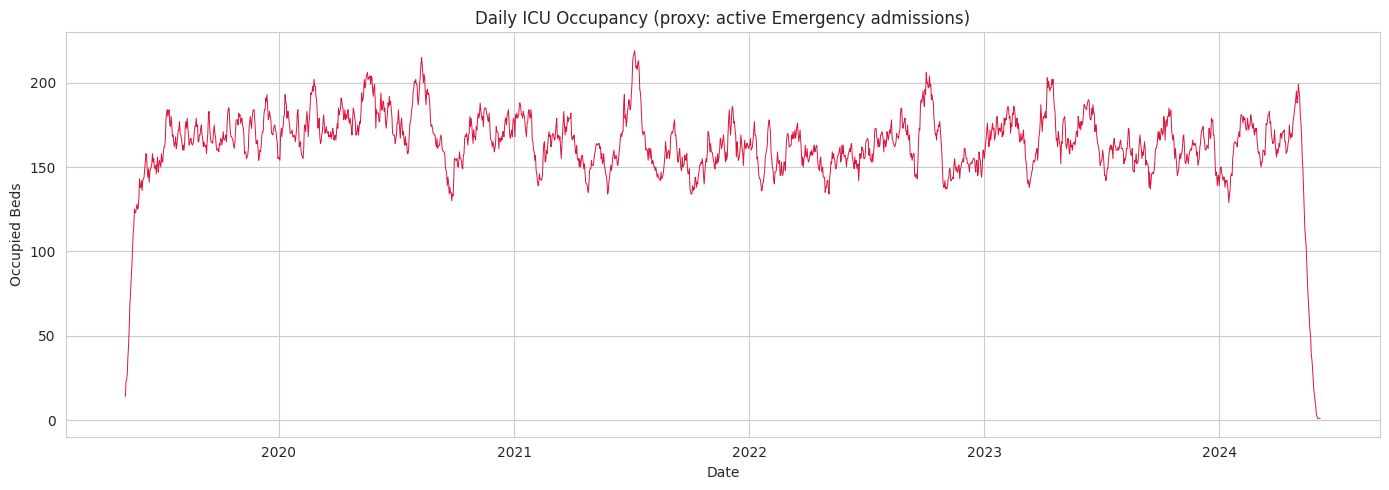

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(icu_occupancy['day'], icu_occupancy['icu_occupancy'], linewidth=0.7, color='crimson')
plt.title('Daily ICU Occupancy (proxy: active Emergency admissions)')
plt.xlabel('Date')
plt.ylabel('Occupied Beds')
plt.tight_layout()
plt.show()


## 10. High-Risk Patients

Flags patients as high-risk using a composite rule: age over 60, an `Abnormal` test result, an `Emergency` admission, or a repeat visit (proxy readmission) — each contributing to a simple risk score. Patients scoring 2+ are surfaced as high-risk.


In [24]:
query_high_risk = '''
WITH patient_visits AS (
    SELECT Name, COUNT(*) AS visit_count
    FROM admissions
    GROUP BY Name
),
risk_flags AS (
    SELECT
        a.Name,
        a.Age,
        a.Medical_Condition,
        a.Admission_Type,
        a.Test_Results,
        v.visit_count,
        (CASE WHEN a.Age > 60 THEN 1 ELSE 0 END) +
        (CASE WHEN a.Test_Results = 'Abnormal' THEN 1 ELSE 0 END) +
        (CASE WHEN a.Admission_Type = 'Emergency' THEN 1 ELSE 0 END) +
        (CASE WHEN v.visit_count > 1 THEN 1 ELSE 0 END) AS risk_score
    FROM admissions a
    JOIN patient_visits v ON a.Name = v.Name
)
SELECT
    Name, Age, Medical_Condition, Admission_Type, Test_Results, visit_count, risk_score
FROM risk_flags
WHERE risk_score >= 2
ORDER BY risk_score DESC, Age DESC
LIMIT 20;
'''
high_risk_patients = pd.read_sql(query_high_risk, conn)
high_risk_patients


,Name,Age,Medical_Condition,Admission_Type,Test_Results,visit_count,risk_score
0,doNALD aViLA,89,Asthma,Emergency,Abnormal,2,4
1,mIchaeL POtTs,89,Hypertension,Emergency,Abnormal,2,4
2,JeNNIfER gonZalez,88,Obesity,Emergency,Abnormal,2,4
3,troY RODriGuEz,88,Arthritis,Emergency,Abnormal,2,4
4,MONiQUE FIgueroA,87,Diabetes,Emergency,Abnormal,2,4
5,MarGaREt mENDeZ,87,Diabetes,Emergency,Abnormal,2,4
6,bEtHANy wOOd,87,Obesity,Emergency,Abnormal,2,4
7,cRYstAL rOLLiNS,87,Cancer,Emergency,Abnormal,2,4
8,mCkEnziE VaZQUEz,87,Asthma,Emergency,Abnormal,2,4
9,jON rEed,86,Arthritis,Emergency,Abnormal,2,4


In [25]:
query_high_risk_summary = '''
WITH patient_visits AS (
    SELECT Name, COUNT(*) AS visit_count
    FROM admissions
    GROUP BY Name
),
risk_flags AS (
    SELECT
        a.Name,
        (CASE WHEN a.Age > 60 THEN 1 ELSE 0 END) +
        (CASE WHEN a.Test_Results = 'Abnormal' THEN 1 ELSE 0 END) +
        (CASE WHEN a.Admission_Type = 'Emergency' THEN 1 ELSE 0 END) +
        (CASE WHEN v.visit_count > 1 THEN 1 ELSE 0 END) AS risk_score
    FROM admissions a
    JOIN patient_visits v ON a.Name = v.Name
)
SELECT
    risk_score,
    COUNT(*) AS record_count
FROM risk_flags
GROUP BY risk_score
ORDER BY risk_score;
'''
high_risk_summary = pd.read_sql(query_high_risk_summary, conn)
high_risk_summary


,risk_score,record_count
0,0,12769
1,1,22464
2,2,15412
3,3,4427
4,4,428


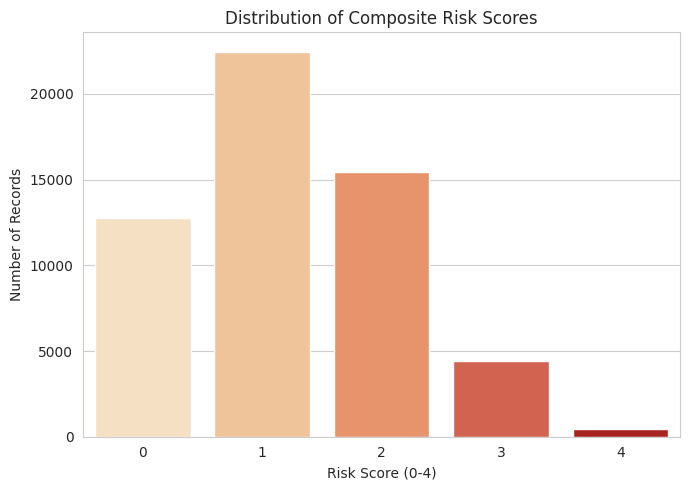

In [26]:
plt.figure(figsize=(7, 5))
sns.barplot(data=high_risk_summary, x='risk_score', y='record_count', palette='OrRd')
plt.title('Distribution of Composite Risk Scores')
plt.xlabel('Risk Score (0-4)')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


## Summary

| # | Business Query | Key Finding Location |
|---|---|---|
| 1 | Top Diseases | Section 1 — ranked bar chart |
| 2 | Monthly Admissions | Section 2 — trend line, ~30/day average, stable across years |
| 3 | Revenue Analysis | Section 3 — yearly + by admission type |
| 4 | Insurance Claims | Section 4 — by provider |
| 5 | Readmission Rate | Section 5 — overall % + by condition (proxy metric) |
| 6 | Department KPIs | Section 6 — proxy via Medical Condition |
| 7 | Doctor Performance | Section 7 — top 15 by volume, billing, LOS |
| 8 | Average Length of Stay | Section 8 — overall + by admission type |
| 9 | ICU Occupancy | Section 9 — daily proxy series via recursive CTE |
| 10 | High-Risk Patients | Section 10 — composite risk score, top 20 surfaced |

**Proxy metrics used throughout** (no patient ID, department, or ICU column exists in the source data): Readmission Rate, Department KPIs, ICU Occupancy, and the readmission component of the High-Risk Patients score. Each is flagged inline where it appears — worth keeping in mind if these numbers get quoted downstream.
